# EchoMS TOF 데이터 분석 파이프라인

EchoMS TOF 질량분석 데이터를 처리하는 전체 워크플로우를 다룹니다.

## 학습 목표
1. **TIC (Total Ion Chromatogram)** 시각화
2. **Background 제거** — 노이즈/블랭크 피크 차감
3. **XIC (Extracted Ion Chromatogram)** — 특정 화합물 m/z 추출 + **Echo drop별 Summation 적분**
4. **MS/MS Fragmentation** 스펙트럼 분석
5. **반응 스킴 기반 Crude 조성 분석** — 면적비로 전환율 계산

### 데이터
- **TOF-MS**: `20260330_TOFMS.mzML` (MS1 full scan, 495 spectra)
- **MRM-HR**: `20260330_MRMHR_Q1Q3_Final.mzML` (MS1 397 + MS/MS 2779)
- **화합물 목록**: `Explosives_EchoMS_20260331.xlsx` (EPA 8330 폭발물 표준물질)

---
## 0. 환경 설정

분석에 필요한 Python 패키지를 설치하고 임포트합니다. 핵심 도구는 다음과 같습니다:

- **pyopenms**: mzML 형식의 질량분석 데이터를 파싱하는 OpenMS Python wrapper
- **scipy**: 베이스라인 보정 (SNIP 알고리즘), 피크 검출 (`find_peaks`)
- **matplotlib**: TIC, XIC, 스펙트럼 등 시각화
- **numpy / pandas**: 수치 연산 및 테이블 데이터 관리

In [1]:
!pip install -q pyopenms scipy matplotlib numpy pandas openpyxl


### 패키지 임포트

데이터 분석에 필요한 핵심 패키지를 로드합니다. `pyopenms`는 질량분석 데이터 처리의 핵심이고, `scipy.signal`의 `savgol_filter`와 `find_peaks`는 스무딩 및 피크 탐색에 사용됩니다. `matplotlib`로 시각화하고, `numpy`/`pandas`로 수치 연산을 수행합니다.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import pyopenms as oms
import openpyxl
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print('모든 패키지 로드 완료.')

All packages loaded.



### 데이터 다운로드
GitHub 리포에서 mzML 파일과 엑셀을 가져옵니다.  
Git LFS 파일이므로 `git clone`으로 받습니다.

In [3]:
import os

DATA_DIR = 'echo-tof-colab/data'
MZML_DIR = f'{DATA_DIR}/mzml'
TOFMS_FILE = f'{MZML_DIR}/20260330_TOFMS.mzML'
MRMHR_FILE = f'{MZML_DIR}/20260330_MRMHR_Q1Q3_Final.mzML'
EXCEL_FILE = f'{DATA_DIR}/Explosives_EchoMS_20260331.xlsx'

print(f'TOF-MS: {os.path.getsize(TOFMS_FILE)/1e6:.1f} MB')
print(f'MRM-HR: {os.path.getsize(MRMHR_FILE)/1e6:.1f} MB')
print(f'Excel:  {os.path.getsize(EXCEL_FILE)/1e3:.0f} KB')


TOF-MS: 74.3 MB
MRM-HR: 44.6 MB
Excel:  224 KB



---
## 1. mzML 데이터 로드 & TIC 시각화

**TIC (Total Ion Chromatogram)**은 각 스캔 시점에서의 전체 이온 강도 합계입니다.  
- X축: Retention Time (분)
- Y축: Total Intensity (counts)

시료에 어떤 성분이 어느 시간대에 용출되는지 전체 윤곽을 보여줍니다.

In [4]:
def load_mzml(filepath):
    """mzML 파일을 로드하여 MSExperiment 객체 반환"""
    exp = oms.MSExperiment
    oms.MzMLFile.load(filepath, exp)
    print(f'로드 완료: {os.path.basename(filepath)}')
    print(f'  스펙트럼 수: {exp.getNrSpectra}')
    print(f'  크로마토그램 수: {exp.getNrChromatograms}')
    
    # MS level 분포
    levels = {}
    for spec in exp:
        lvl = spec.getMSLevel
        levels[lvl] = levels.get(lvl, 0) + 1
    for lvl, cnt in sorted(levels.items):
        print(f'  MS{lvl}: {cnt} spectra')
    return exp

exp_tof = load_mzml(TOFMS_FILE)

Loaded: 20260330_TOFMS.mzML
  Spectra: 495
  Chromatograms: 2
  MS1: 495 spectra


### TIC 추출 및 시각화

`extract_tic` 함수는 각 MS1 스캔에서 모든 이온의 intensity를 합산하여 하나의 TIC 포인트를 만듭니다. 이를 시간축으로 이어붙이면 TIC 크로마토그램이 완성됩니다.

- **X축**: Retention Time (RT) -- 시료가 검출기를 통과하는 시간 (분)
- **Y축**: Total Ion Intensity -- 해당 시점의 전체 이온 신호 합계
- EchoMS는 연속 주입 방식이므로, TIC에서 **뾰족한 spike**가 보이면 해당 시점에 echo drop이 주입된 것입니다
- spike가 없는 구간은 시료가 없는 baseline (배경 노이즈)입니다

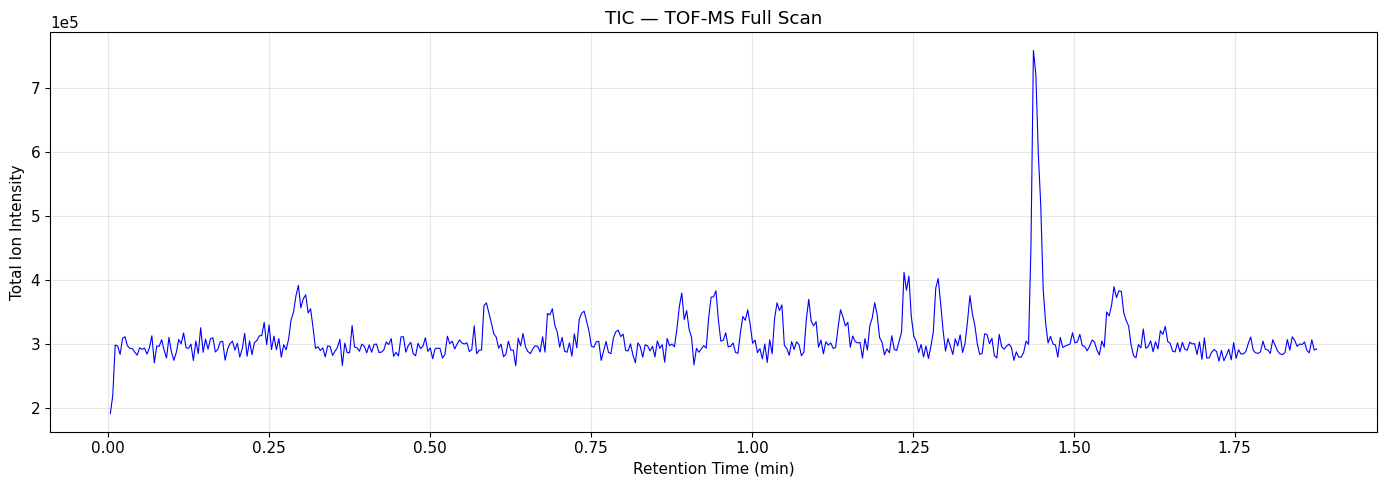

Scan range: 0.00 ~ 1.88 min
TIC max: 7.59e+05 at 1.44 min


In [5]:
def extract_tic(exp, ms_level=1):
    """TIC 추출: 각 MS1 스캔의 intensity 합"""
    rt_list, tic_list = [], []
    for spec in exp:
        if spec.getMSLevel == ms_level:
            rt_list.append(spec.getRT / 60.0)  # 초 → 분
            mz, intensity = spec.get_peaks
            tic_list.append(np.sum(intensity))
    return np.array(rt_list), np.array(tic_list)

rt_tof, tic_tof = extract_tic(exp_tof)

plt.figure(figsize=(14, 5))
plt.plot(rt_tof, tic_tof, 'b-', linewidth=0.8)
plt.xlabel('Retention Time (min)')
plt.ylabel('Total Ion Intensity')
plt.title('TIC — TOF-MS Full Scan')
plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.grid(alpha=0.3)
plt.tight_layout
plt.show

print(f'스캔 범위: {rt_tof[0]:.2f} ~ {rt_tof[-1]:.2f} min')
print(f'TIC 최대: {tic_tof.max:.2e} at {rt_tof[np.argmax(tic_tof)]:.2f} min')

---
## 2. Background 제거

TIC에는 컬럼 블리딩, 용매 클러스터, 전자 노이즈 등의 **background 신호**가 포함됩니다.  
이를 제거하는 두 가지 방법을 구현합니다:

### 2-1. SNIP (Statistics-sensitive Non-linear Iterative Peak-clipping)
- 스펙트럼의 baseline을 반복적으로 깎아내는 알고리즘
- 피크를 보존하면서 기저선만 추정

### 2-2. Median 기반 Background 추정
- 각 m/z bin에서 전체 시간에 걸친 median intensity를 background로 간주
- 시간 독립적인 상시 존재 이온을 제거

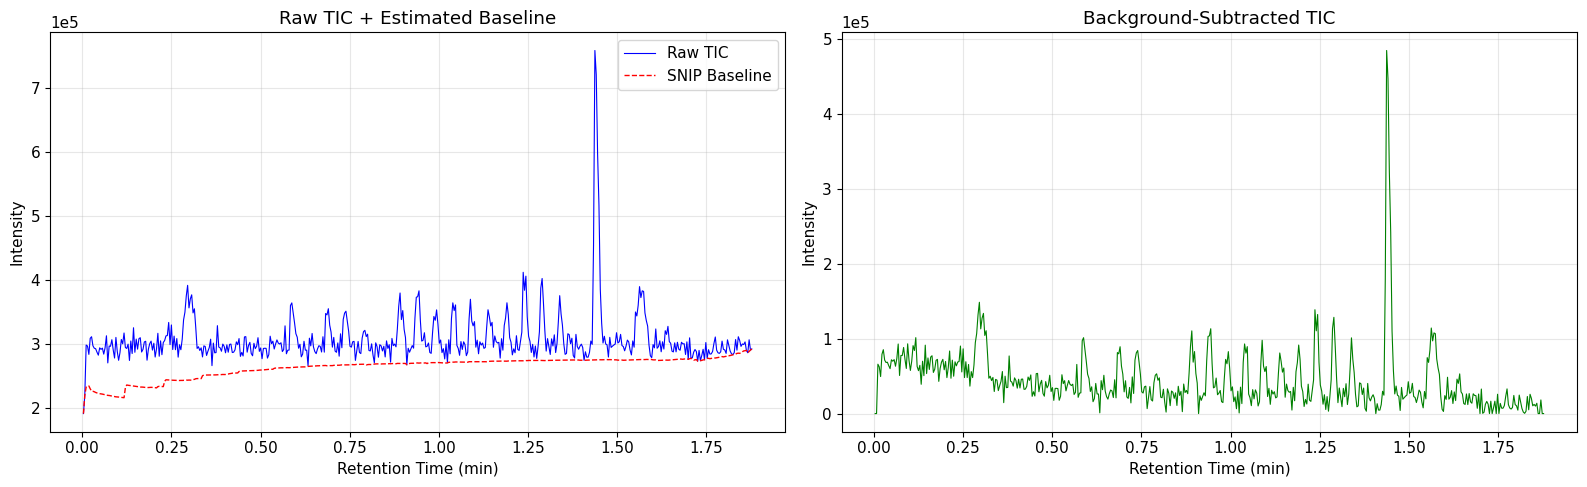

Background removal: 85.6%


In [6]:
def snip_baseline(y, n_iterations=40):
    """SNIP baseline estimation
    
    반복적으로 log-scale에서 인접 점의 평균과 비교하여
    피크를 깎아내고 baseline만 남김
    """
    y_work = np.log(np.log(np.sqrt(np.maximum(y, 1.0)) + 1.0) + 1.0)
    
    for p in range(1, n_iterations + 1):
        y_new = np.copy(y_work)
        for i in range(p, len(y_work) - p):
            avg = (y_work[i - p] + y_work[i + p]) / 2.0
            y_new[i] = min(y_work[i], avg)
        y_work = y_new
    
    # 역변환
    baseline = (np.exp(np.exp(y_work) - 1.0) - 1.0) ** 2
    return baseline

# TIC에 SNIP 적용
baseline_tof = snip_baseline(tic_tof, n_iterations=30)
tic_corrected = np.maximum(tic_tof - baseline_tof, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(rt_tof, tic_tof, 'b-', linewidth=0.8, label='Raw TIC')
axes[0].plot(rt_tof, baseline_tof, 'r--', linewidth=1.0, label='SNIP Baseline')
axes[0].set_title('Raw TIC + Estimated Baseline')
axes[0].set_xlabel('Retention Time (min)')
axes[0].set_ylabel('Intensity')
axes[0].legend
axes[0].grid(alpha=0.3)
axes[0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

axes[1].plot(rt_tof, tic_corrected, 'g-', linewidth=0.8)
axes[1].set_title('Background-Subtracted TIC')
axes[1].set_xlabel('Retention Time (min)')
axes[1].set_ylabel('Intensity')
axes[1].grid(alpha=0.3)
axes[1].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout
plt.show

removed_pct = (1 - tic_corrected.sum / tic_tof.sum) * 100
print(f'Background 제거율: {removed_pct:.1f}%')

---
## 3. 화합물 스킴 & XIC 추출

### 화합물 스킴이란?
분석 대상 화합물의 목록과 각각의 **precursor m/z**, **adduct type** 정보입니다.  
엑셀 파일에서 로드합니다.

### XIC (Extracted Ion Chromatogram)
특정 m/z ± tolerance 범위의 이온만 추출한 크로마토그램입니다.  

**원리:**
1. 매 스캔(시점)마다 전체 mass spectrum이 있음
2. 그 중에서 **target m/z 근방의 intensity만 합산** → 한 포인트
3. 모든 스캔에 대해 반복 → 시간축 크로마토그램 완성

TIC가 "전체 사진"이라면, XIC는 **특정 화합물의 초상화**입니다.

```
Scan 1 (0.00 min): [전체 spectrum] → m/z 226 근방 합산 → XIC point 1
Scan 2 (0.01 min): [전체 spectrum] → m/z 226 근방 합산 → XIC point 2
Scan 3 (0.02 min): [전체 spectrum] → m/z 226 근방 합산 → XIC point 3
...이것을 이어붙이면 XIC
```

---

**Next:** [Mass Spectrum](02%20Mass%20Spectrum.ipynb) ➡️